In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("✅ Libraries loaded!")
print("Fraud Detection Model ready 🔍💳")

ModuleNotFoundError: No module named 'imblearn'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("✅ Libraries loaded!")
print("Fraud Detection Model ready 🔍💳")

ImportError: sklearn._cyutility does not export expected C function slice_memviewslice

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("✅ Libraries loaded!")
print("Fraud Detection Model ready 🔍💳")

✅ Libraries loaded!
Fraud Detection Model ready 🔍💳


In [4]:
np.random.seed(42)

n = 10000

df = pd.DataFrame({
    'transaction_amount':  np.random.exponential(100, n),
    'account_age_days':    np.random.randint(1, 3650, n),
    'transactions_per_day': np.random.randint(1, 50, n),
    'distance_from_home':  np.random.exponential(50, n),
    'hour_of_day':         np.random.randint(0, 24, n),
    'is_foreign':          np.random.randint(0, 2, n),
    'failed_attempts':     np.random.randint(0, 5, n),
    'credit_score':        np.random.randint(300, 850, n),
})

risk = (
    df['transaction_amount'] / 500 * 0.3 +
    df['failed_attempts'] / 4 * 0.3 +
    df['is_foreign'] * 0.2 +
    df['distance_from_home'] / 200 * 0.1 +
    (df['hour_of_day'] < 6).astype(int) * 0.1
)

df['is_fraud'] = (risk > 0.5).astype(int)

print(f"Total transactions: {len(df)}")
print(f"Fraud rate: {df['is_fraud'].mean()*100:.1f}%")
print(df['is_fraud'].value_counts())

Total transactions: 10000
Fraud rate: 21.3%
is_fraud
0    7871
1    2129
Name: count, dtype: int64


In [5]:
print ("===Basic stats==="

_IncompleteInputError: incomplete input (1815889826.py, line 1)

In [6]:
print("=== Basic Stats ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Basic Stats ===
       transaction_amount  account_age_days  transactions_per_day  \
count        10000.000000      10000.000000          10000.000000   
mean            97.749895       1824.080600             25.037200   
std             97.440471       1044.816194             14.100386   
min              0.001163          1.000000              1.000000   
25%             28.279917        926.750000             13.000000   
50%             67.831496       1815.000000             25.000000   
75%            134.709830       2734.500000             37.000000   
max            817.244560       3649.000000             49.000000   

       distance_from_home   hour_of_day    is_foreign  failed_attempts  \
count        10000.000000  10000.000000  10000.000000      10000.00000   
mean            50.374939     11.500700      0.493400          2.01030   
std             50.182735      6.983128      0.499981          1.41513   
min              0.001026      0.000000      0.000000         

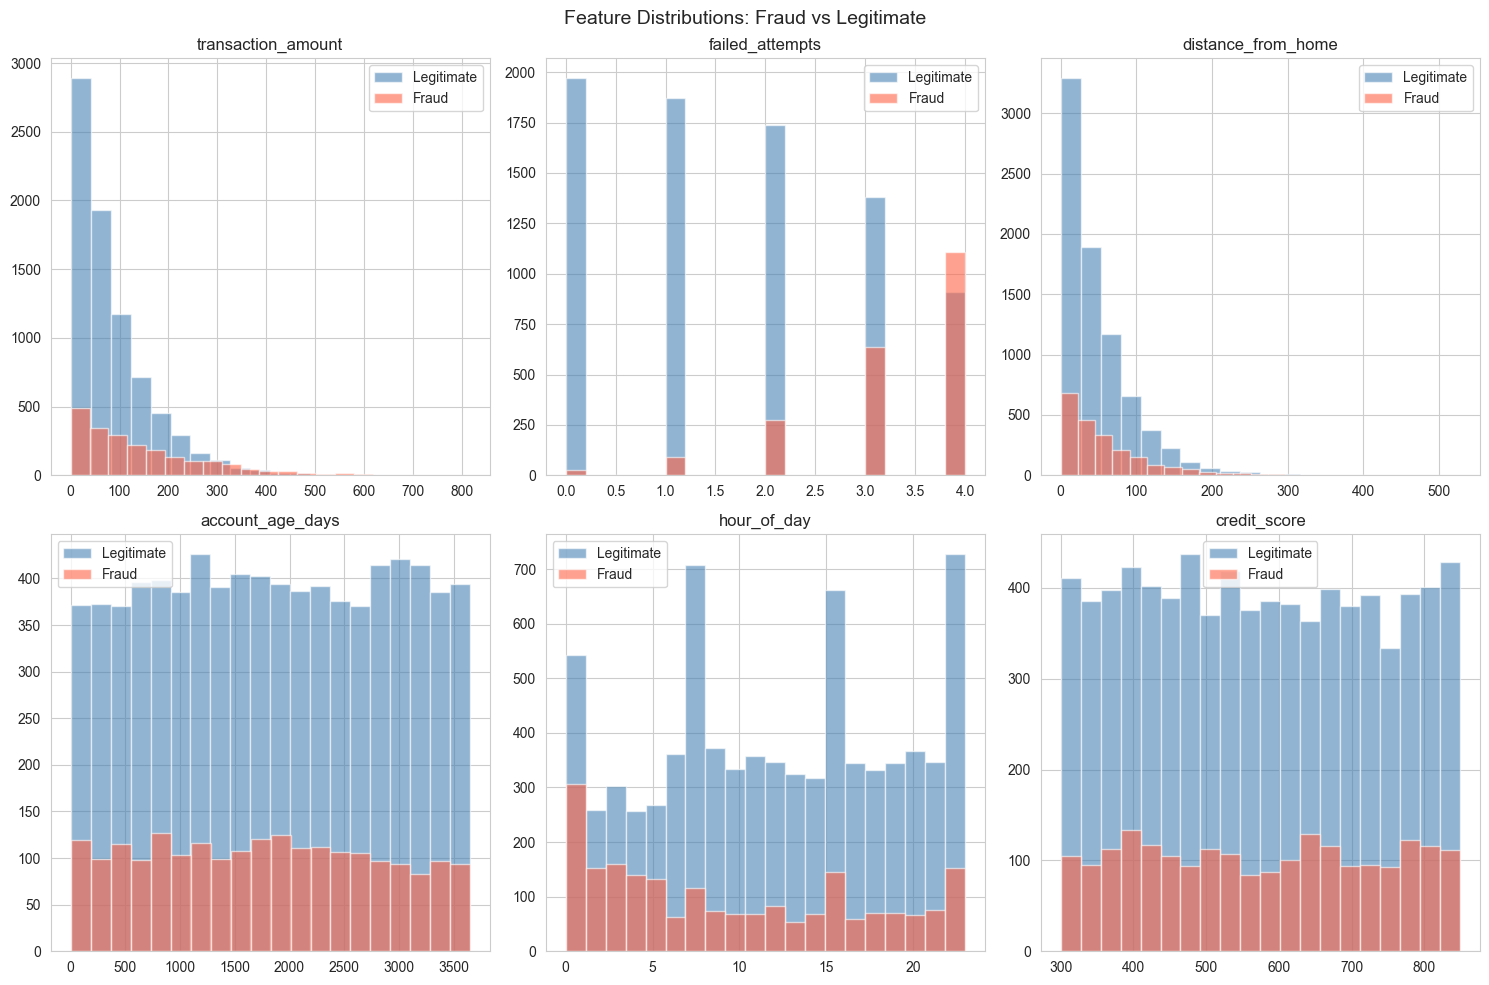

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Distributions: Fraud vs Legitimate', fontsize=14)

features = ['transaction_amount', 'failed_attempts', 'distance_from_home', 
            'account_age_days', 'hour_of_day', 'credit_score']

for ax, feature in zip(axes.flatten(), features):
    df[df['is_fraud'] == 0][feature].hist(ax=ax, alpha=0.6, label='Legitimate', color='steelblue', bins=20)
    df[df['is_fraud'] == 1][feature].hist(ax=ax, alpha=0.6, label='Fraud', color='tomato', bins=20)
    ax.set_title(feature)
    ax.legend()

plt.tight_layout()
plt.show()

In [8]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)

print("=== Fraud Detection Model Results ===")
print(classification_report(y_test, predictions, target_names=['Legitimate', 'Fraud']))

=== Fraud Detection Model Results ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      1547
       Fraud       0.98      0.96      0.97       453

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000



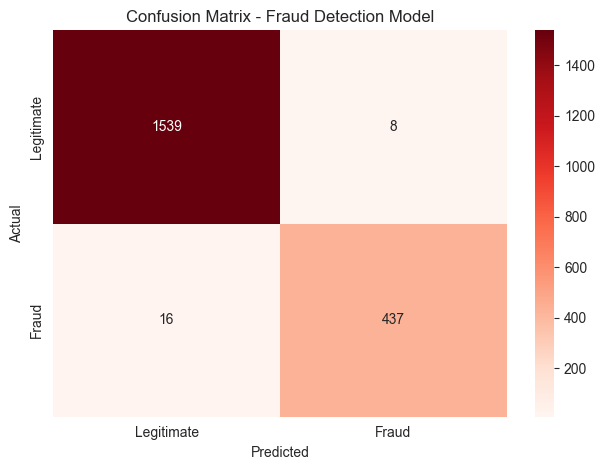

✅ Legitimate transactions correctly cleared: 1539
✅ Fraudulent transactions correctly caught:  437
❌ Fraud cases missed:                        16
❌ Legitimate transactions wrongly flagged:   8


In [9]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])

plt.title('Confusion Matrix - Fraud Detection Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"✅ Legitimate transactions correctly cleared: {tn}")
print(f"✅ Fraudulent transactions correctly caught:  {tp}")
print(f"❌ Fraud cases missed:                        {fn}")
print(f"❌ Legitimate transactions wrongly flagged:   {fp}")